<a href="https://colab.research.google.com/github/elianedp/ExpertSystem/blob/main/jupyter_pandas_workshop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**introdução**

Esta atividade tem como objetivo aplicar as bibliotecas pandas, matplotlib e seaborn para explorar e visualizar dados na área da saúde.
o conjunto de dados utilizado contém informações de pacientes hospitalares, como idade, datas de internação e alta, tipo de serviço e nível de satisfação.
a proposta é compreender melhor o comportamento dos dados, realizar pequenas análises e representar os resultados por meio de três gráficos diferentes.

In [8]:
# Atividade Formativa: Explorando Dados em Saúde com Bibliotecas do Python
# Disciplina: IA Aplicada à Saúde
# Autora: Eliane Maria de Pieri

# Importando as bibliotecas principais
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações gerais dos gráficos
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]
sns.set(style="whitegrid")

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


In [9]:
# Carregar o dataset de pacientes
df = pd.read_csv('patients.csv')

# Visualizar as 5 primeiras linhas da tabela
df.head()

,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76


In [10]:
# verificando as informações do conjunto de dados
print("Informações do DataFrame:")
df.info()

# visualizando algumas estatísticas básicas das colunas numéricas
print("\nEstatísticas descritivas:")
display(df.describe())

# verificando se há valores nulos nas colunas
print("\nVerificando valores nulos:")
print(df.isnull().sum())

Informações do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2   age             1000 non-null   int64 
 3   arrival_date    1000 non-null   object
 4   departure_date  1000 non-null   object
 5   service         1000 non-null   object
 6   satisfaction    1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB

Estatísticas descritivas:


,age,satisfaction
count,1000.000000,1000.000000
mean,45.337000,79.597000
std,25.999912,11.550325
min,0.000000,60.000000
25%,23.000000,70.000000
50%,46.000000,80.000000
75%,68.000000,89.250000
max,89.000000,99.000000



Verificando valores nulos:
patient_id        0
name              0
age               0
arrival_date      0
departure_date    0
service           0
satisfaction      0
dtype: int64


In [11]:
# convertendo as colunas de data para o formato datetime
df['arrival_date'] = pd.to_datetime(df['arrival_date'], errors='coerce')
df['departure_date'] = pd.to_datetime(df['departure_date'], errors='coerce')

# criando uma nova coluna com a quantidade de dias internado
df['days_hospitalized'] = (df['departure_date'] - df['arrival_date']).dt.days

# conferindo o resultado
df[['patient_id', 'arrival_date', 'departure_date', 'days_hospitalized']].head()

,patient_id,arrival_date,departure_date,days_hospitalized
0,PAT-09484753,2025-03-16,2025-03-22,6
1,PAT-f0644084,2025-12-13,2025-12-14,1
2,PAT-ac6162e4,2025-06-29,2025-07-05,6
3,PAT-3dda2bb5,2025-10-12,2025-10-23,11
4,PAT-08591375,2025-02-18,2025-02-25,7


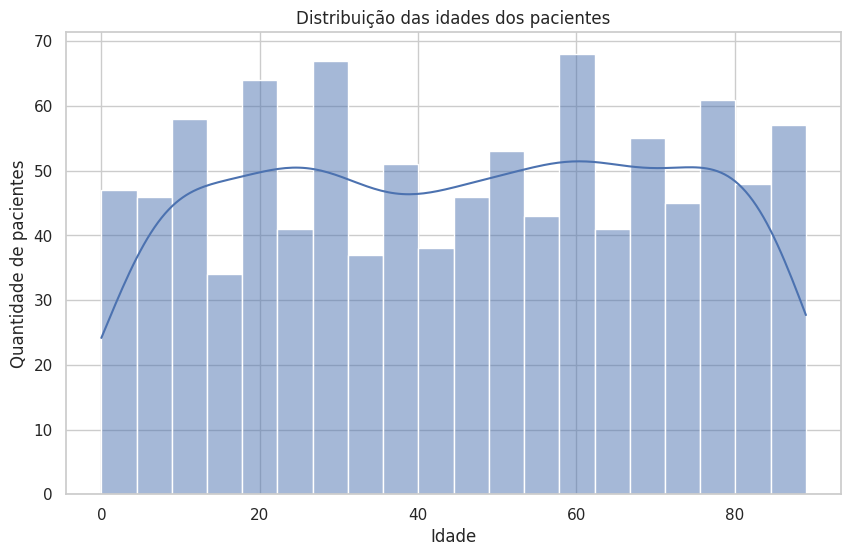

In [12]:
# analisando a distribuição das idades dos pacientes
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribuição das idades dos pacientes')
plt.xlabel('Idade')
plt.ylabel('Quantidade de pacientes')
plt.show()

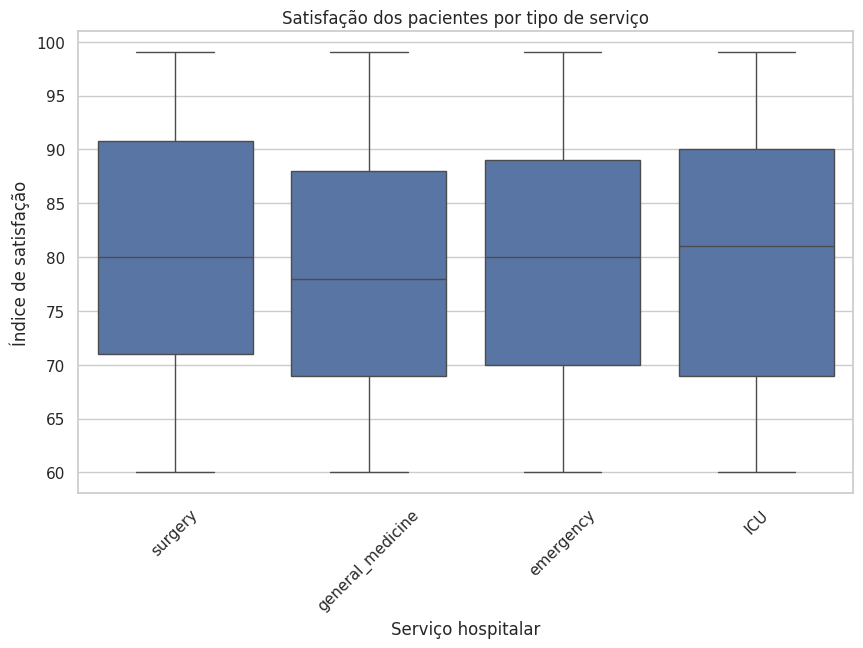

In [13]:
# comparando o nível de satisfação entre os diferentes serviços
sns.boxplot(x='service', y='satisfaction', data=df)
plt.title('Satisfação dos pacientes por tipo de serviço')
plt.xlabel('Serviço hospitalar')
plt.ylabel('Índice de satisfação')
plt.xticks(rotation=45)
plt.show()

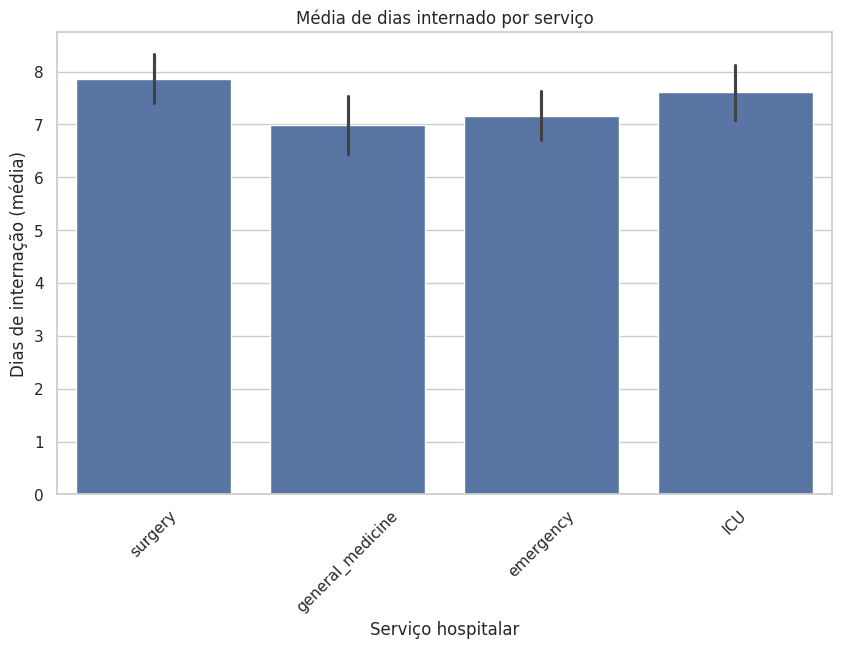

In [14]:
# analisando o tempo médio de internação em cada serviço
sns.barplot(x='service', y='days_hospitalized', data=df, estimator='mean')
plt.title('Média de dias internado por serviço')
plt.xlabel('Serviço hospitalar')
plt.ylabel('Dias de internação (média)')
plt.xticks(rotation=45)
plt.show()

**análise e considerações**

nesta atividade, explorei um conjunto de dados de pacientes hospitalares para praticar o uso das bibliotecas pandas, matplotlib e seaborn.
primeiro, fiz a leitura e preparação dos dados, convertendo as colunas de data e criando a coluna com a quantidade de dias internado.
em seguida, gerei três gráficos diferentes: a distribuição de idades dos pacientes, a comparação do nível de satisfação entre os serviços e a média de dias internados por serviço.
a partir dessas visualizações, é possível observar o perfil dos pacientes, o desempenho de cada área e como o tempo de internação varia entre os tipos de atendimento.